In [1]:
import sys
sys.path.append("..")

In [2]:
from src.data import load_glass_data

df = load_glass_data(target="Tg")

X = df.drop(columns=["Tg"])
y = df["Tg"]

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Target range: {y.min():.1f} - {y.max():.1f} °C")

Features: 19
Samples: 42205
Target range: 65.0 - 1222.0 °C


In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f} °C")
print(f"R²: {r2:.4f}")

RMSE: 34.44 °C
R²: 0.9365


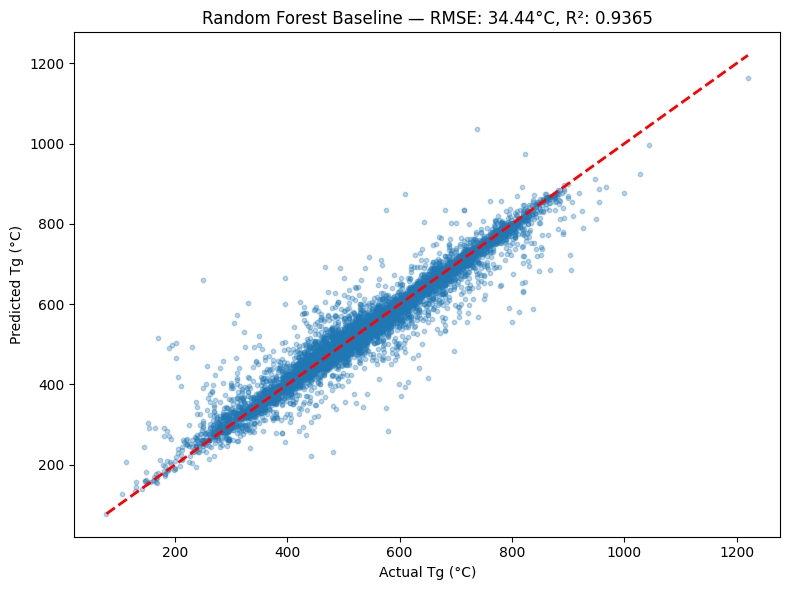

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2)
plt.xlabel("Actual Tg (°C)")
plt.ylabel("Predicted Tg (°C)")
plt.title(f"Random Forest Baseline — RMSE: {rmse:.2f}°C, R²: {r2:.4f}")
plt.tight_layout()
plt.savefig("../outputs/baseline_rf.png", dpi=150)
plt.show()

In [5]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost RMSE: {rmse_xgb:.2f} °C")
print(f"XGBoost R²: {r2_xgb:.4f}")
print()
print(f"RF RMSE:      {rmse:.2f} °C")
print(f"RF R²:        {r2:.4f}")

XGBoost RMSE: 37.91 °C
XGBoost R²: 0.9231

RF RMSE:      34.44 °C
RF R²:        0.9365


In [6]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

rf_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [20, 30, 40, None],
    "max_features": [0.3, 0.5, 0.7],
    "min_samples_leaf": [1, 2, 4],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)

print(f"Best params: {rf_search.best_params_}")
y_pred_rf_tuned = rf_search.predict(X_test)
rmse_rf_tuned = root_mean_squared_error(y_test, y_pred_rf_tuned)
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)
print(f"Tuned RF RMSE: {rmse_rf_tuned:.2f} °C")
print(f"Tuned RF R²:   {r2_rf_tuned:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'n_estimators': 500, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': 40}
Tuned RF RMSE: 33.56 °C
Tuned RF R²:   0.9397


In [7]:
from xgboost import XGBRegressor

xgb_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=xgb_param_grid,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

xgb_search.fit(X_train, y_train)

print(f"Best params: {xgb_search.best_params_}")
y_pred_xgb_tuned = xgb_search.predict(X_test)
rmse_xgb_tuned = root_mean_squared_error(y_test, y_pred_xgb_tuned)
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)
print(f"Tuned XGBoost RMSE: {rmse_xgb_tuned:.2f} °C")
print(f"Tuned XGBoost R²:   {r2_xgb_tuned:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Tuned XGBoost RMSE: 33.84 °C
Tuned XGBoost R²:   0.9387
